# 1. Setup and Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics torch torchvision matplotlib opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.3 MB/s eta 0:00:00


# 2. Paths to Your Combined Dataset

In [ ]:
import os

# Paths to your combined dataset (adjust if needed)
combined_root = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset'
images_dir = os.path.join(combined_root, 'images')
labels_dir = os.path.join(combined_root, 'labels')

# Output directory for cropped cells
crops_root = '/content/cropped_cells'
os.makedirs(crops_root, exist_ok=True)

# 3. Crop Cells from Images (Using Ground Truth Labels)

In [ ]:
import cv2
import numpy as np
from tqdm import tqdm

def crop_cells_from_split(split_name):
    """Crop cells from a split (train, val, test) using ground truth labels."""
    img_dir = os.path.join(images_dir, split_name)
    lbl_dir = os.path.join(labels_dir, split_name)
    out_dir = os.path.join(crops_root, split_name)

    for cls_name in ['RBC', 'WBC', 'Platelets']:
        os.makedirs(os.path.join(out_dir, cls_name), exist_ok=True)

    for img_file in tqdm(os.listdir(img_dir), desc=f'Cropping {split_name}'):
        if not img_file.endswith(('.jpg','.png')):
            continue
        img_path = os.path.join(img_dir, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        label_file = img_file.replace('.jpg','.txt').replace('.png','.txt')
        label_path = os.path.join(lbl_dir, label_file)
        if not os.path.exists(label_path):
            continue

        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                xc *= w
                yc *= h
                bw *= w
                bh *= h
                x1 = int(xc - bw/2)
                y1 = int(yc - bh/2)
                x2 = int(xc + bw/2)
                y2 = int(yc + bh/2)
                # Ensure within image bounds
                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(w, x2)
                y2 = min(h, y2)
                if x2 <= x1 or y2 <= y1:
                    continue
                crop = img[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                crop = cv2.resize(crop, (64, 64))
                cls_name = ['RBC', 'WBC', 'Platelets'][cls_id]
                save_path = os.path.join(out_dir, cls_name, f'{img_file}_{x1}_{y1}.jpg')
                cv2.imwrite(save_path, crop)

# Run for train, val, test
for split in ['train', 'val', 'test']:
    crop_cells_from_split(split)

Cropping test: 100%|██████████| 60/60 [01:18<00:00,  1.30s/it]


# 4. Load Cropped Dataset and Create DataLoaders

In [ ]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Transformations for training (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# No augmentation for validation/test
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(crops_root, 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(crops_root, 'val'), transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(crops_root, 'test'), transform=val_test_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Train samples: 3220
Val samples: 782
Test samples: 842


# 5. Train ResNet‑18 Classifier

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(pretrained=True)
model.fc = torch.nn.Linear(512, 3)   # 3 classes
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

epochs = 15
best_val_acc = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100 * correct / total
    scheduler.step(val_loss)

    print(f'Epoch {epoch+1}/{epochs} | Train Loss: {running_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_cnn.pth')
        print('  -> Saved best model')

print(f'Best validation accuracy: {best_val_acc:.2f}%')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 75.0MB/s]


Epoch 1/15 | Train Loss: 0.1230 | Val Loss: 0.0188 | Val Acc: 99.36%
  -> Saved best model
Epoch 2/15 | Train Loss: 0.0411 | Val Loss: 0.0263 | Val Acc: 99.23%
Epoch 3/15 | Train Loss: 0.0265 | Val Loss: 0.0195 | Val Acc: 99.10%
Epoch 4/15 | Train Loss: 0.0349 | Val Loss: 0.0121 | Val Acc: 99.49%
  -> Saved best model
Epoch 5/15 | Train Loss: 0.0138 | Val Loss: 0.0033 | Val Acc: 99.87%
  -> Saved best model
Epoch 6/15 | Train Loss: 0.0171 | Val Loss: 0.0041 | Val Acc: 99.87%
Epoch 7/15 | Train Loss: 0.0249 | Val Loss: 0.9193 | Val Acc: 65.22%
Epoch 8/15 | Train Loss: 0.0125 | Val Loss: 0.0290 | Val Acc: 99.49%
Epoch 9/15 | Train Loss: 0.0185 | Val Loss: 0.0013 | Val Acc: 100.00%
  -> Saved best model
Epoch 10/15 | Train Loss: 0.0120 | Val Loss: 0.0023 | Val Acc: 100.00%
Epoch 11/15 | Train Loss: 0.0089 | Val Loss: 0.0036 | Val Acc: 99.87%
Epoch 12/15 | Train Loss: 0.0192 | Val Loss: 0.0210 | Val Acc: 99.23%
Epoch 13/15 | Train Loss: 0.0102 | Val Loss: 0.0008 | Val Acc: 100.00%
Epoch 14

# 6. Save Model and Cropped Dataset to Drive

In [ ]:
# Save model to Drive
!cp /content/best_cnn.pth "/content/drive/MyDrive/blood_cell_project/cnn_model.pth"
print("CNN model saved to Drive.")

CNN model saved to Drive.


In [ ]:
!cp -r /content/cropped_cells "/content/drive/MyDrive/blood_cell_project/"print("Cropped dataset saved to Drive.")

Cropped dataset saved to Drive.


# 7. Evaluate Clean Accuracy on Test Set

In [14]:
model.load_state_dict(torch.load('/content/drive/MyDrive/blood_cell_project/cnn_model.pth'))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
clean_acc = 100 * correct / total
print(f'Clean test accuracy: {clean_acc:.2f}%')

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

# 8. Patch Evaluation on Cropped Cells

In [28]:
import random
from torchvision import transforms as T

def create_shaky_patch_cell(img_tensor, patch_size=(160,160), blur_ksize=(5,5), sigma=3):
    """Generate a shaky patch from the input image tensor."""
    # Convert tensor to PIL for easier cropping
    to_pil = T.ToPILImage()
    img_pil = to_pil(img_tensor.cpu())
    w, h = img_pil.size
    pw, ph = patch_size
    if pw > w or ph > h:
        pw, ph = w, h
    x = random.randint(0, w - pw)
    y = random.randint(0, h - ph)
    crop = img_pil.crop((x, y, x+pw, y+ph))
    # Apply Gaussian blur
    from PIL import ImageFilter
    crop_blurred = crop.filter(ImageFilter.GaussianBlur(radius=sigma))
    # Convert back to tensor
    crop_tensor = T.ToTensor()(crop_blurred)
    return crop_tensor

def overlay_patch_cell(img_tensor, patch_tensor, position=(0,0)):
    """Overlay patch tensor onto image tensor (both 3xHxW)."""
    _, h, w = img_tensor.shape
    _, ph, pw = patch_tensor.shape
    x, y = position
    # Ensure patch fits
    if x + pw > w or y + ph > h:
        patch_tensor = T.Resize((h-y, w-x))(patch_tensor)
        _, ph, pw = patch_tensor.shape
    img_patched = img_tensor.clone()
    img_patched[:, y:y+ph, x:x+pw] = patch_tensor
    return img_patched

def evaluate_patches_cnn(model, test_loader, device, num_placements=5):
    patch_types = ['gray', 'white', 'black', 'shaky']
    results = {pt: {'correct': 0, 'total': 0} for pt in patch_types}
    results['clean'] = {'correct': 0, 'total': 0}

    # Pre‑compute solid patches (size 160x160)
    gray_patch = torch.full((3,160,160), 0.5, device=device)          # mid‑gray (normalised 0-1)
    white_patch = torch.full((3,160,160), 1.0, device=device)
    black_patch = torch.full((3,160,160), 0.0, device=device)
    solid_patches = {'gray': gray_patch, 'white': white_patch, 'black': black_patch}

    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            # Clean accuracy
            outputs = model(images)
            _, pred = torch.max(outputs, 1)
            results['clean']['correct'] += (pred == labels).sum().item()
            results['clean']['total'] += labels.size(0)

            # For each patch type, evaluate with random placements
            for pt in patch_types:
                # For each image in the batch, we need to apply placements and average predictions
                batch_preds = []
                for img_tensor in images:
                    # For each placement, get prediction
                    preds_per_placement = []
                    for _ in range(num_placements):
                        if pt == 'shaky':
                            patch_tensor = create_shaky_patch_cell(img_tensor, patch_size=(160,160))
                            patch_tensor = patch_tensor.to(device)
                        else:
                            patch_tensor = solid_patches[pt]
                        # Random position
                        _, h, w = img_tensor.shape
                        _, ph, pw = patch_tensor.shape
                        x = random.randint(0, w - pw) if w - pw > 0 else 0
                        y = random.randint(0, h - ph) if h - ph > 0 else 0
                        img_patched = overlay_patch_cell(img_tensor, patch_tensor, (x,y))
                        # Predict
                        out = model(img_patched.unsqueeze(0))
                        _, pred_placement = torch.max(out, 1)
                        preds_per_placement.append(pred_placement.item())
                    # Majority vote
                    final_pred = max(set(preds_per_placement), key=preds_per_placement.count)
                    batch_preds.append(final_pred)
                # Compare with true labels for this batch
                for i, pred in enumerate(batch_preds):
                    if pred == labels[i].item():
                        results[pt]['correct'] += 1
                    results[pt]['total'] += 1

    # Compute accuracies
    accuracies = {}
    accuracies['clean'] = 100 * results['clean']['correct'] / results['clean']['total']
    for pt in patch_types:
        accuracies[pt] = 100 * results[pt]['correct'] / results[pt]['total']
    return accuracies

# Run evaluation
print('Evaluating clean and patched accuracies on cropped test set...')
cnn_results = evaluate_patches_cnn(model, test_loader, device, num_placements=5)
print("\n=== CNN Classifier Results ===")
print(f"Clean accuracy: {cnn_results['clean']:.2f}%")
print(f"Gray patch:     {cnn_results['gray']:.2f}%")
print(f"White patch:    {cnn_results['white']:.2f}%")
print(f"Black patch:    {cnn_results['black']:.2f}%")
print(f"Shaky patch:    {cnn_results['shaky']:.2f}%")

Evaluating clean and patched accuracies on cropped test set...

=== CNN Classifier Results ===
Clean accuracy: 100.00%
Gray patch:     84.80%
White patch:    84.92%
Black patch:    84.80%
Shaky patch:    87.17%


# 9. Save Results and Example Images

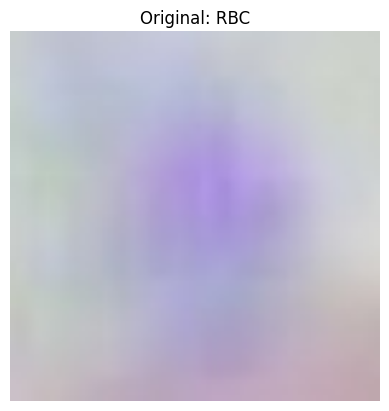

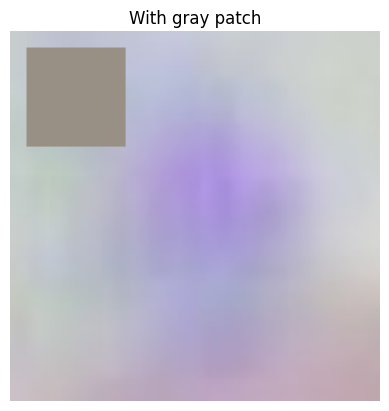

In [19]:
import matplotlib.pyplot as plt

# Save a few example original vs patched images (first batch)
images, labels = next(iter(test_loader))
img = images[0].cpu()
label = labels[0].item()
class_names = ['RBC', 'WBC', 'Platelets']

# Original
plt.imshow(img.permute(1,2,0) * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406]))
plt.title(f'Original: {class_names[label]}')
plt.axis('off')
plt.savefig('/content/original_cell.png')
plt.show()

# Example with gray patch
patch = torch.full((3,160,160), 0.5)
img_patched = overlay_patch_cell(img, patch, (10,10))
plt.imshow(img_patched.permute(1,2,0) * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406]))
plt.title('With gray patch')
plt.axis('off')
plt.savefig('/content/patched_cell.png')
plt.show()

# 10. Save Evaluation Results And Images

In [20]:
import json
results = {
    'clean_accuracy': clean_acc,
    'gray_accuracy': cnn_results['gray'],
    'white_accuracy': cnn_results['white'],
    'black_accuracy': cnn_results['black'],
    'shaky_accuracy': cnn_results['shaky']
}
with open('/content/cnn_results.json', 'w') as f:
    json.dump(results, f)
!cp /content/cnn_results.json "/content/drive/MyDrive/blood_cell_project/"

In [21]:
!cp /content/original_cell.png "/content/drive/MyDrive/blood_cell_project/"
!cp /content/patched_cell.png "/content/drive/MyDrive/blood_cell_project/"